# Spotify Product Analytics Project

## Notebook 2 — Event Modeling & Feature Engineering

### Objective

This notebook focuses on:
- transforming streaming data into an event system
- building session-based analytics
- engineering behavioral features
- creating user-level analytical datasets

This notebook simulates how modern product analytics systems model:
- engagement
- sessions
- retention behavior
- user habits
- churn signals

DATA LOADING

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

streaming_df = pd.read_csv(
    "../cleaned_data/streaming_cleaned.csv"
)

streaming_df['ts'] = pd.to_datetime(streaming_df['ts'])

streaming_df.head()

,ts,platform,ms_played,conn_country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,minutes_played,date,hour,day_name,month,week,is_weekend,skip_flag,night_listener,long_play
0,2020-06-21 13:35:24,Windows 10 (10.0.19041; x64; AppX),205906,IN,Let Me Love You,DJ Snake,Encore,spotify:track:5Qjv35Ja2TDt9CXRRo51hh,playbtn,trackdone,False,False,False,False,3.431767,2020-06-21,13,Sunday,6,25,True,0,0,0
1,2020-06-21 13:39:37,Windows 10 (10.0.19041; x64; AppX),252534,IN,"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,Delirium,spotify:track:3zHq9ouUJQFQRf3cm1rRLu,trackdone,trackdone,True,False,False,False,4.208900,2020-06-21,13,Sunday,6,25,True,0,0,0
2,2020-06-21 13:42:51,Windows 10 (10.0.19041; x64; AppX),193266,IN,Mueve La Cintura,Pitbull,Libertad 548,spotify:track:6iLyEBNStoAemStXqGY7qP,trackdone,trackdone,True,False,False,False,3.221100,2020-06-21,13,Sunday,6,25,True,0,0,0
3,2020-06-21 13:45:23,Windows 10 (10.0.19041; x64; AppX),151133,IN,Lean On (with Emiway Bantai),Celina Sharma,Lean On (with Emiway Bantai),spotify:track:61eDLrQvquaTtZRnGFz9Kh,trackdone,endplay,True,False,False,False,2.518883,2020-06-21,13,Sunday,6,25,True,0,0,0
4,2020-06-21 13:48:30,Windows 10 (10.0.19041; x64; AppX),176000,IN,Sniper,Sukh-E Muzical Doctorz,Sniper,spotify:track:4H1sP4qqOYy4WXtfb0O3mz,playbtn,trackdone,True,False,False,False,2.933333,2020-06-21,13,Sunday,6,25,True,0,0,0


EVENT MODELING

In [ ]:
# CREATE EVENT ID
streaming_df = streaming_df.reset_index(drop=True)

streaming_df['event_id'] = streaming_df.index + 1

In [ ]:
#CREATE EVENT TYPE
streaming_df['event_type'] = 'music_play'

In [17]:
#COMPLETION EVENNT
streaming_df['completion_rate'] = (
    streaming_df['ms_played'] /
    streaming_df['ms_played'].max()
)

In [18]:
streaming_df['fully_played'] = np.where(
    streaming_df['completion_rate'] > 0.8,
    1,
    0
)

In [19]:
#ENGAGEMENT EVENT CATEGORIES
conditions = [
    streaming_df['ms_played'] < 30000,
    streaming_df['ms_played'].between(30000, 180000),
    streaming_df['ms_played'] > 180000
]

choices = [
    'skip',
    'normal_engagement',
    'high_engagement'
]

streaming_df['engagement_level'] = np.select(
    conditions,
    choices,
    default='unknown'
)

SESSIONIZATION

In [20]:
#SORT DATA
streaming_df = streaming_df.sort_values('ts')

In [21]:
#TIME DIFFERENCE
streaming_df['time_diff'] = (
    streaming_df['ts']
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [22]:
#CREATE NEW SESSION FLAG
streaming_df['new_session'] = np.where(
    streaming_df['time_diff'] > 30,
    1,
    0
)

In [23]:
#CREATE NEW SESSION IDs
streaming_df['session_id'] = (
    streaming_df['new_session']
    .cumsum()
)

SESSION ANALYTICS

In [24]:
#TRACKS PER SESSION
session_tracks = (
    streaming_df
    .groupby('session_id')
    .size()
    .reset_index(name='tracks_per_session')
)

In [25]:
#SESSION DURATION
session_duration = (
    streaming_df
    .groupby('session_id')['minutes_played']
    .sum()
    .reset_index(name='session_duration')
)

In [26]:
#SESSION SKIP RATE
session_skip = (
    streaming_df
    .groupby('session_id')['skip_flag']
    .mean()
    .reset_index(name='session_skip_rate')
)

In [27]:
#MERGE SESSION METRICS
session_df = (
    session_tracks
    .merge(session_duration, on='session_id')
    .merge(session_skip, on='session_id')
)

session_df.head()

,session_id,tracks_per_session,session_duration,session_skip_rate
0,0,6,19.933017,0.000000
1,1,1,3.103300,0.000000
2,2,2,0.793167,0.500000
3,3,1,0.434333,1.000000
4,4,19,62.268817,0.052632


ADVANCED BEHAVIORAL FEATURES

In [28]:
#BINGE LISTENER
session_avg = (
    session_df['session_duration']
    .mean()
)

session_df['binge_session'] = np.where(
    session_df['session_duration'] > session_avg,
    1,
    0
)

In [29]:
#SHUFFLE BEHAVIOUR
shuffle_behavior = (
    streaming_df
    .groupby('session_id')['shuffle']
    .mean()
    .reset_index(name='shuffle_rate')
)

USER LEVEL AGGREGATION

In [30]:
#USER LEVEL METRICS
user_df = (
    streaming_df
    .groupby('platform')
    .agg({
        'minutes_played': ['sum', 'mean'],
        'session_id': 'nunique',
        'skip_flag': 'mean',
        'track_name': 'count'
    })
)

user_df

minutes_played            \
                                                              sum      mean   
platform                                                                      
Android OS 7.0 API 24 (Xiaomi, Redmi Note 4)         28866.891633  2.373336   
Android OS 9 API 28 (Xiaomi, Redmi Note 5 Pro)         765.602250  2.251771   
Android-tablet OS 11 API 30 (SAMSUNG, SM-T870)        3557.362567  2.485928   
Android-tablet OS 11 API 30 (realme, RMP2102)         3197.830467  2.469367   
Android-tablet OS 7.0 API 24 (Xiaomi, Redmi Not...     180.715350  1.673290   
OS X 12.5.0 [arm 2]                                     14.765683  1.845710   
OS X 12.5.1 [arm 2]                                   1166.596600  2.482120   
OS X 12.6.0 [arm 2]                                    862.053117  2.498705   
Windows 10 (10.0.18362; x64; AppX)                     115.901550  1.632416   
Windows 10 (10.0.18363; x64; AppX)                     145.049717  1.198758   
Windows 10 (10.0.19041; x64)                           116.347400  2.281322   
Windows 10 (10.0.19041; x64; AppX)                     391.513200  2.387276   
Windows 10 (10.0.19042; x64; AppX)                    4359.074617  1.902695   
android                                              68603.377650  3.080806   
osx                                                  30400.901767  3.164783   
web_player osx 10.15.7;chrome 91.0.4472.114;des...      39.067550  1.860360   
web_player osx 10.15.7;chrome 91.0.4472.164;des...      39.229783  2.179432   
web_player osx 10.15.7;chrome 97.0.4692.99;desktop      53.485950  2.431180   
web_player osx 10.15.7;safari 14.1.1;desktop           379.263417  2.370396   
web_player osx 10.15.7;safari 15.1;desktop             356.172617  2.406572   
web_player osx 10.15.7;safari 15.2;desktop             554.891283  2.860264   
web_player osx 10.15.7;safari 15.3;desktop            1179.251083  2.827940   
web_player osx 10.15.7;safari 15.4;desktop             140.158850  1.946651   
web_player osx 10.15.7;safari 15.5;desktop            1059.469833  1.940421   
web_player osx 10.15.7;safari 15.6.1;desktop            44.010817  2.445045   
web_player osx 10.15.7;safari 15.6;desktop             447.156867  1.810352   
web_player osx 10.15;firefox 100.0;desktop               9.458783  1.891757   
web_player osx 10.15;firefox 101.0;desktop              17.434683  1.937187   
web_player osx 10.15;firefox 103.0;desktop              19.154333  1.741303   
web_player osx 10.15;firefox 90.0;desktop              540.569067  2.055396   
web_player osx 10.15;firefox 91.0;desktop              581.479367  2.517227   
web_player osx 10.15;firefox 92.0;desktop              391.272550  2.755440   
web_player osx 10.15;firefox 93.0;desktop              158.124933  2.360074   
web_player osx 10.15;firefox 94.0;desktop              546.971733  2.409567   
web_player osx 10.15;firefox 95.0;desktop              950.450883  2.412312   
web_player osx 10.15;firefox 96.0;desktop               98.436917  2.187487   
web_player osx 10.15;firefox 97.0;desktop               28.664000  2.605818   
web_player osx 10.15;firefox 98.0;desktop               15.086117  2.155160   
web_player osx 10.15;firefox 99.0;desktop               57.079750  2.038562   
web_player windows 10;chrome 100.0.4896.75;desktop      28.357317  3.544665   
web_player windows 10;chrome 89.0.4389.90;desktop       48.673050  2.212411   
web_player windows 10;chrome 92.0.4515.107;desktop      24.028883  2.402888   
web_player windows 10;microsoft edge 102.0.1245...      20.438683  1.277418   
web_player windows 10;microsoft edge 88.0.705.5...      93.716167  2.037308   
web_player windows 10;microsoft edge 89.0.774.5...      19.511883  1.951188   
web_player windows 10;microsoft edge 91.0.864.4...      66.615717  2.775655   

                                                   session_id skip_flag  \
                                                      nunique      mean   
platform                     

USER ENGAGEMENT

In [31]:
streaming_df['engagement_score'] = (
    (streaming_df['minutes_played'] * 0.5)
    +
    (streaming_df['fully_played'] * 30)
    -
    (streaming_df['skip_flag'] * 20)
)

In [32]:
#ENGAGEMENT DISTRIBUTION
streaming_df['engagement_level'].value_counts()

engagement_level
high_engagement      28243
normal_engagement    17741
skip                  8187
Name: count, dtype: int64

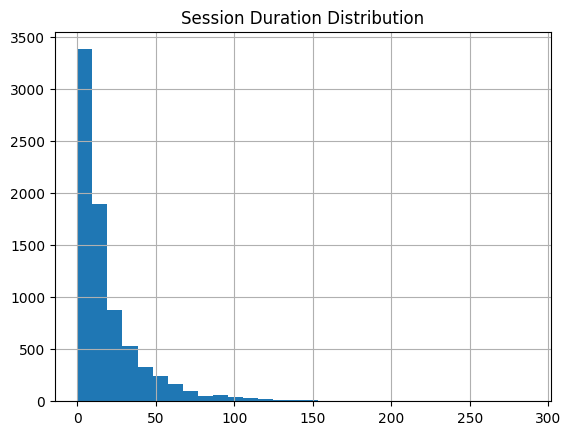

In [33]:
#SESSION DISTRIBUTION
session_df['session_duration'].hist(
    bins=30
)

plt.title("Session Duration Distribution")

plt.show()

In [34]:
#SKIP RATE ANALYSIS
streaming_df.groupby(
    'engagement_level'
)['skip_flag'].mean()

engagement_level
high_engagement      0.0
normal_engagement    0.0
skip                 1.0
Name: skip_flag, dtype: float64

EXPORT DATA

In [38]:
streaming_df.to_csv(
    "../analytics_data/events.csv",
    index=False
)

In [40]:
session_df.to_csv(
    "../analytics_data/sessions.csv",
    index=False
)